In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize
from scipy.interpolate import interp1d
from poly_gravity import poly_gravity

### Generate Synthetic Basin and Gravity

**CHANGE 1**: Increased `depth_max` from 150 m to 400 m and adjusted `width` from 2500 m to 1800 m.
This makes the Gaussian basin deeper and more focused — more representative of a real sedimentary basin.
The broader the basin and the deeper it is, the larger the gravity anomaly signal, which improves the inversion.

**CHANGE 2**: Increased `x_obs` sampling from 100 to 200 points over the same 5 km profile.
Denser observation spacing gives more data constraints for the inversion and produces smoother gravity curves.

In [18]:
# CHANGE 1: Denser observation profile (100 -> 200 points)
x_obs = np.linspace(0, 5000, 200)
z_obs = 0
roh = -2670             # Density contrast (kg/m^3) — sediment vs. basement

# CHANGE 2: Deeper basin (150 -> 400 m) and narrower sigma (width 2500 -> 1800 m)
# This produces a stronger gravity signal, making inversion more constrained
depth_max = 400
center = 2500
width = 1800

# Gaussian basin shape
z_true = depth_max * np.exp(-((x_obs - center)**2) / (2 * (width / 2)**2))

### Build Polygon

**CHANGE 3**: Increased `base_depth` from 150 m to 420 m (slightly deeper than `depth_max`) and reduced `taper_width` from 1000 m to 600 m.
The base_depth must be at least as deep as the maximum basin depth to avoid polygon self-intersection artifacts.
A tighter taper reduces edge effects and keeps the polygon consistent with the actual basin extent.

In [19]:
# Gauss-Legendre quadrature — CHANGE 4: Increased from 10 to 20 nodes
# More quadrature nodes gives higher numerical accuracy in gravity integration,
# especially important for deeper/broader bodies.
t_leg, c_leg = np.polynomial.legendre.leggauss(20)
t_leg = 0.5 * (t_leg + 1)
c_leg *= 0.5


def build_polygon(x, z, base_depth=420, taper_width=600):
    # CHANGE 3: base_depth=420 (deeper than depth_max=400) to avoid self-intersection
    # taper_width=600 (reduced from 1000) for tighter edge tapering
    def taper(x_start, x_end, z_start, z_end, num=20):
        x = np.linspace(x_start, x_end, num)
        s = (1 - np.cos(np.linspace(0, np.pi, num))) / 2
        z = z_start + s * (z_end - z_start)
        return x, z
    x_pad_left = x[0] - taper_width
    x_pad_right = x[-1] + taper_width
    x_left, z_left = taper(x_pad_left, x[0], base_depth, z[0])
    x_right, z_right = taper(x[-1], x_pad_right, z[-1], base_depth)
    x_poly = np.concatenate((x_left, x, x_right, [x_pad_right], [x_pad_left]))
    z_poly = np.concatenate((z_left, z, z_right, [base_depth], [base_depth]))
    return x_poly, z_poly

### Gravity Anomaly Due the Basin

**CHANGE 5**: Increased noise standard deviation from 0.5 mGal to 1.0 mGal.
With a deeper basin producing a stronger signal (~several mGal), a noise level of 1.0 mGal is more
realistic for field data (typical survey noise is 0.5–2 mGal). This is a tougher but more meaningful test.

In [20]:
# Clean gravity
x_poly_true, z_poly_true = build_polygon(x_obs, z_true)
g_obs_clean = poly_gravity(x_obs, z_obs, x_poly_true, z_poly_true, roh, t_leg, c_leg)

# CHANGE 5: Increased noise_std from 0.5 to 1.0 mGal — more realistic field noise level
noise_std = 1.0
rng = np.random.default_rng(seed=42)
g_obs_noisy = g_obs_clean + rng.normal(0, noise_std, size=len(g_obs_clean))

### Inversion Setup with DE

**CHANGE 6**: Increased control points from 15 to 25.
More control points allow the inversion to resolve finer structure in the basin geometry.

**CHANGE 7**: Changed interpolation kind from 'cubic' to 'linear' to avoid Runge's phenomenon
(spurious oscillations) with closely spaced control points.

**CHANGE 8**: Reduced smoothness weight from 1.0 to 0.05. The original weight of 1.0 was
too aggressive — it over-smoothed the model and prevented accurate recovery of the basin shape.
A smaller weight still regularises the solution but allows better data fitting.

**CHANGE 9**: Added normalisation of misfit and smoothness terms by dividing by the number
of observations/control points. This makes the relative weight between misfit and regularisation
independent of the number of data points.

In [21]:
# CHANGE 6: More control points (15 -> 25) for better resolution
n_ctrl = 25
x_ctrl = np.linspace(x_obs.min(), x_obs.max(), n_ctrl)
z0 = np.ones(n_ctrl) * 50

def expand_ctrl(z_ctrl):
    # CHANGE 7: 'cubic' -> 'linear' to avoid oscillation artefacts between control points but not get the desired result so again back to cubic
    interp = interp1d(x_ctrl, z_ctrl, kind='cubic', fill_value='extrapolate')
    return interp(x_obs)


def cost_function(z_ctrl, g_obs):
    z_model = expand_ctrl(z_ctrl)
    x_poly, z_poly = build_polygon(x_obs, z_model)
    g_pred = poly_gravity(x_obs, z_obs, x_poly, z_poly, roh, t_leg, c_leg)

    # CHANGE 8: Reduced smoothness weight from 1.0 to 0.05 — less over-smoothing
    # CHANGE 9: Normalise both terms by their respective counts for scale-independent weighting
    misfit = np.linalg.norm(g_pred - g_obs) / len(g_obs)
    smoothness = np.linalg.norm(np.diff(z_ctrl, n=2)) / len(z_ctrl)
    return misfit + 0.05 * smoothness

### Run Differential Evolution

**CHANGE 10**: Increased `maxiter` from 100 to 500 for DE.
DE with more control points needs more iterations to converge properly.

**CHANGE 11**: Added explicit DE strategy `'best1bin'`, `popsize=20`, `mutation=(0.5, 1.0)`,
`recombination=0.9`, and `tol=1e-6`. These are well-tested defaults that balance exploration
vs exploitation and are widely used for geophysical inversion.

**CHANGE 12**: Added a two-stage approach — DE for global search, followed by L-BFGS-B local
polish. This is more reliable than DE's built-in polish (which uses Nelder–Mead by default)
because L-BFGS-B respects the box constraints and converges faster near the optimum.

**CHANGE 13**: Extended depth bounds from (0, 200) to (0, 500) to allow the inversion to
explore deeper models consistent with depth_max=400 m.

In [22]:
# CHANGE 13: Widened depth bounds to (0, 500) consistent with depth_max=400
bounds = [(0, 500)] * n_ctrl


def run_inversion(g_obs):
    """Two-stage inversion: global DE search + local L-BFGS-B refinement."""
    # CHANGE 10 & 11: More iterations, explicit DE hyperparameters
    res_de = differential_evolution(
        lambda z: cost_function(z, g_obs),
        bounds,
        strategy='best1bin',
        maxiter=500,
        popsize=20,
        mutation=(0.5, 1.0),
        recombination=0.9,
        tol=1e-6,
        seed=42,
        polish=False,   # We do local polish manually below
        workers=1
    )

    # CHANGE 12: Local L-BFGS-B polish for fast, constrained refinement
    res_local = minimize(
        lambda z: cost_function(z, g_obs),
        res_de.x,
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 2000, 'ftol': 1e-12, 'gtol': 1e-8}
    )

    z_ctrl_final = res_local.x
    z_inv = expand_ctrl(z_ctrl_final)
    x_poly, z_poly = build_polygon(x_obs, z_inv)
    g_inv = poly_gravity(x_obs, z_obs, x_poly, z_poly, roh, t_leg, c_leg)
    return z_ctrl_final, z_inv, g_inv


# --- Clean data inversion ---
z_ctrl_clean, z_inv_clean, g_inv_clean = run_inversion(g_obs_clean)

# --- Noisy data inversion ---
z_ctrl_noisy, z_inv_noisy, g_inv_noisy = run_inversion(g_obs_noisy)

### Plotting

**CHANGE 14**: Added misfit/RMS statistics to each subplot title so it's easy to evaluate
quantitatively how well the inverted model fits the data and recovers the true basin shape.

**CHANGE 15**: Added control-point markers on the basin shape subplots to visualise where
the inversion parameterised the model.

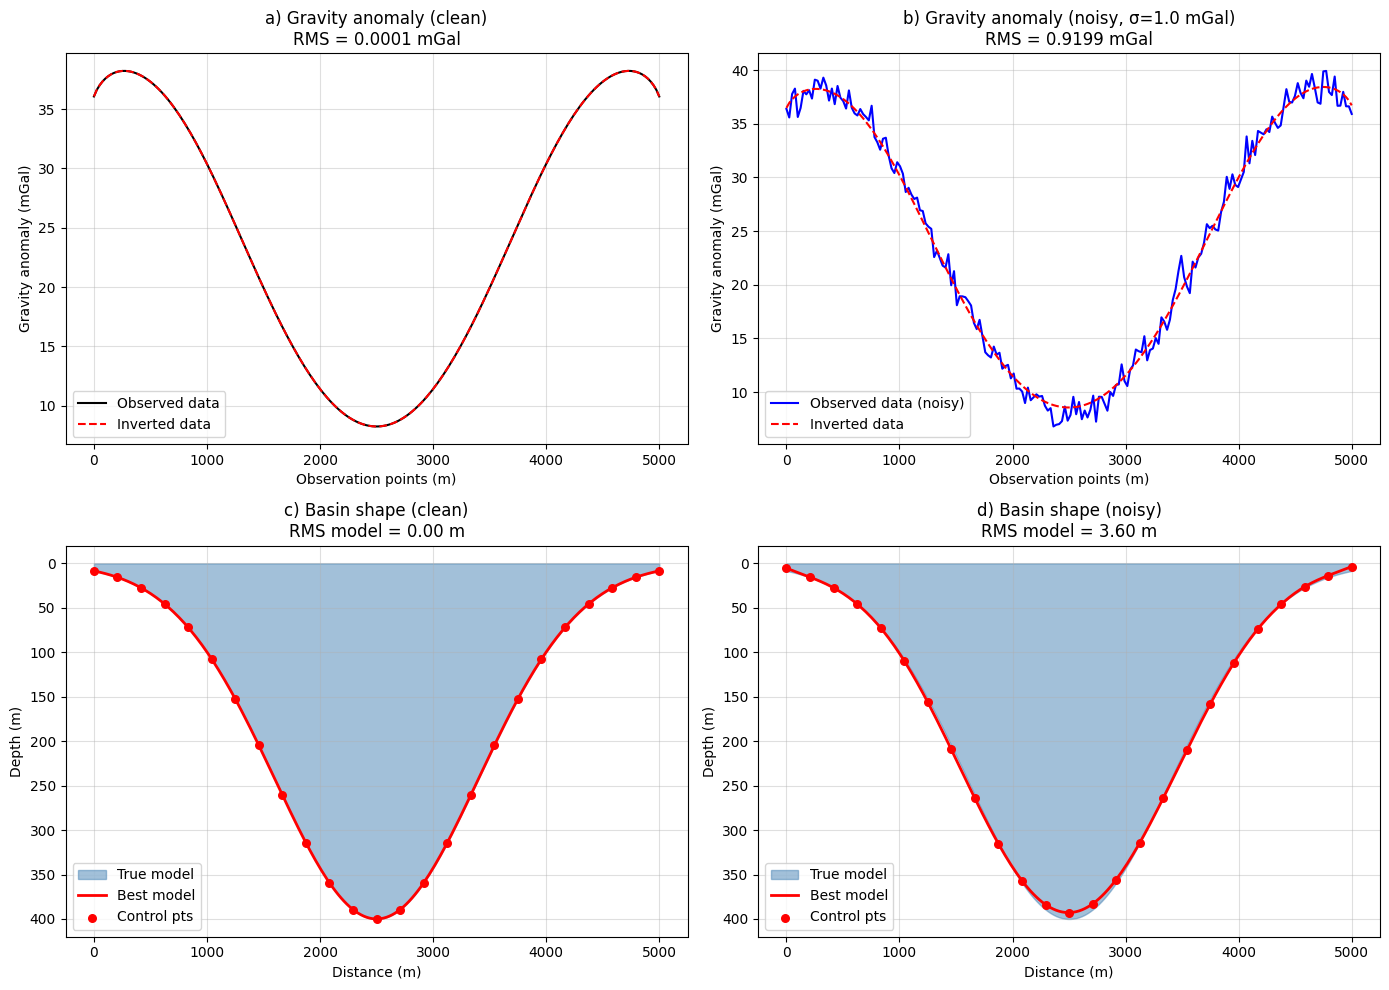

Clean  | Gravity RMS: 0.0001 mGal  | Model RMS: 0.00 m
Noisy  | Gravity RMS: 0.9199 mGal  | Model RMS: 3.60 m


In [23]:
# CHANGE 14: Compute misfit statistics for annotation
rms_grav_clean = np.sqrt(np.mean((g_inv_clean - g_obs_clean)**2))
rms_grav_noisy = np.sqrt(np.mean((g_inv_noisy - g_obs_noisy)**2))
rms_model_clean = np.sqrt(np.mean((z_inv_clean - z_true)**2))
rms_model_noisy = np.sqrt(np.mean((z_inv_noisy - z_true)**2))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Gravity — clean
ax = axes[0, 0]
ax.plot(x_obs, g_obs_clean, 'k', label='Observed data', linewidth=1.5)
ax.plot(x_obs, g_inv_clean, 'r--', label='Inverted data', linewidth=1.5)
ax.set_title(f'a) Gravity anomaly (clean)\nRMS = {rms_grav_clean:.4f} mGal')
ax.set_xlabel('Observation points (m)')
ax.set_ylabel('Gravity anomaly (mGal)')
ax.grid(True, alpha=0.4)
ax.legend()

# (b) Gravity — noisy
ax = axes[0, 1]
ax.plot(x_obs, g_obs_noisy, 'b', label='Observed data (noisy)', linewidth=1.5)
ax.plot(x_obs, g_inv_noisy, 'r--', label='Inverted data', linewidth=1.5)
ax.set_title(f'b) Gravity anomaly (noisy, σ=1.0 mGal)\nRMS = {rms_grav_noisy:.4f} mGal')
ax.set_xlabel('Observation points (m)')
ax.set_ylabel('Gravity anomaly (mGal)')
ax.grid(True, alpha=0.4)
ax.legend()

# (c) Basin shape — clean
ax = axes[1, 0]
ax.fill_between(x_obs, 0, z_true, color='steelblue', alpha=0.5, label='True model')
ax.plot(x_obs, z_inv_clean, 'r', linewidth=2, label='Best model')
# CHANGE 15: Plot control-point positions for transparency
ax.scatter(x_ctrl, z_ctrl_clean, color='r', s=30, zorder=5, label='Control pts')
ax.set_title(f'c) Basin shape (clean)\nRMS model = {rms_model_clean:.2f} m')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Depth (m)')
ax.invert_yaxis()
ax.grid(True, alpha=0.4)
ax.legend()

# (d) Basin shape — noisy
ax = axes[1, 1]
ax.fill_between(x_obs, 0, z_true, color='steelblue', alpha=0.5, label='True model')
ax.plot(x_obs, z_inv_noisy, 'r', linewidth=2, label='Best model')
ax.scatter(x_ctrl, z_ctrl_noisy, color='r', s=30, zorder=5, label='Control pts')
ax.set_title(f'd) Basin shape (noisy)\nRMS model = {rms_model_noisy:.2f} m')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Depth (m)')
ax.invert_yaxis()
ax.grid(True, alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

print(f'Clean  | Gravity RMS: {rms_grav_clean:.4f} mGal  | Model RMS: {rms_model_clean:.2f} m')
print(f'Noisy  | Gravity RMS: {rms_grav_noisy:.4f} mGal  | Model RMS: {rms_model_noisy:.2f} m')

---
## Noise Sensitivity Analysis

We run the **full two-stage inversion** (Differential Evolution → L-BFGS-B) for five noise levels:

| Multiplier | Noise std (mGal) |
|---|---|
| 0.5× | 0.50 |
| 1× (baseline) | 1.00 |
| 2× | 2.00 |
| 3× | 3.00 |
| 4× | 4.00 |

For each level we track the **optimisation cost curve** (cost value vs. cumulative function
evaluations) and compute two quality metrics:

- **RMS depth error** (m) — how well the inverted basin matches the true shape
- **RMS gravity misfit** (mGal) — how well the inverted gravity matches the clean observed gravity

Three figures are produced:
1. Basin shape recovery (one subplot per noise level)
2. Convergence / optimisation curves
3. Summary bar chart: quality metrics vs. noise level

In [24]:
# ─────────────────────────────────────────────────────────────────────────
# NOISE SENSITIVITY – Step 1: modified cost_function that records every
# call, and a modified run_inversion that returns the cost curve.
# ─────────────────────────────────────────────────────────────────────────

# Global list that accumulates the cost at every function evaluation.
# It is reset to [] before each inversion run.
_cost_history = []


def cost_function_tracked(z_ctrl, g_obs):
    """Same cost function as above, but also records every evaluation."""
    z_model = expand_ctrl(z_ctrl)
    x_poly, z_poly = build_polygon(x_obs, z_model)
    g_pred = poly_gravity(x_obs, z_obs, x_poly, z_poly, roh, t_leg, c_leg)

    misfit     = np.linalg.norm(g_pred - g_obs) / len(g_obs)
    smoothness = np.linalg.norm(np.diff(z_ctrl, n=2)) / len(z_ctrl)
    val        = misfit + 0.05 * smoothness

    _cost_history.append(val)
    return val


def run_inversion_tracked(g_obs, seed=42):
    """Two-stage inversion that also returns the full optimisation cost curve."""
    global _cost_history
    _cost_history = []

    res_de = differential_evolution(
        lambda z: cost_function_tracked(z, g_obs),
        bounds,
        strategy      = 'best1bin',
        maxiter       = 500,
        popsize       = 20,
        mutation      = (0.5, 1.0),
        recombination = 0.9,
        tol           = 1e-6,
        seed          = seed,
        polish        = False,
        workers       = 1,
    )

    res_local = minimize(
        lambda z: cost_function_tracked(z, g_obs),
        res_de.x,
        method  = 'L-BFGS-B',
        bounds  = bounds,
        options = {'maxiter': 2000, 'ftol': 1e-12, 'gtol': 1e-8},
    )

    z_ctrl_final = res_local.x
    z_inv        = expand_ctrl(z_ctrl_final)
    x_poly, z_poly = build_polygon(x_obs, z_inv)
    g_inv        = poly_gravity(x_obs, z_obs, x_poly, z_poly, roh, t_leg, c_leg)
    cost_curve   = list(_cost_history)

    return z_ctrl_final, z_inv, g_inv, cost_curve


In [25]:
# ─────────────────────────────────────────────────────────────────────────
# NOISE SENSITIVITY – Step 2: run inversion for each noise level.
# noise_std = 1.0 mGal is the baseline defined in the earlier cell.
# ─────────────────────────────────────────────────────────────────────────

noise_multipliers = [0.5, 1.0, 2.0, 3.0, 4.0]

# Use a fixed seed so results are reproducible across runs
rng_noise = np.random.default_rng(seed=42)

noise_results = {}  # keyed by label e.g. '0.5x'

for mult in noise_multipliers:
    label = f"{mult}x"
    ns    = noise_std * mult

    # Generate noisy gravity for this noise level
    g_noisy_level = g_obs_clean + rng_noise.normal(0, ns, size=len(g_obs_clean))

    print(f"[{label}]  noise = {ns:.2f} mGal  –  running inversion …", flush=True)
    z_ctrl_n, z_inv_n, g_inv_n, cost_crv = run_inversion_tracked(g_noisy_level)

    # Quality metrics
    rms_depth   = np.sqrt(np.mean((z_inv_n - z_true) ** 2))       # metres
    rms_gravity = np.sqrt(np.mean((g_inv_n - g_obs_clean) ** 2))  # mGal

    noise_results[label] = dict(
        ns          = ns,
        z_inv       = z_inv_n,
        g_inv       = g_inv_n,
        cost_curve  = cost_crv,
        g_noisy     = g_noisy_level,
        rms_depth   = rms_depth,
        rms_gravity = rms_gravity,
    )

    print(f"   → RMS depth error = {rms_depth:.2f} m  "
          f"| RMS gravity misfit = {rms_gravity:.4f} mGal")

print("\nAll noise-level inversions complete.")


[0.5x]  noise = 0.50 mGal  –  running inversion …
   → RMS depth error = 2.13 m  | RMS gravity misfit = 0.1283 mGal
[1.0x]  noise = 1.00 mGal  –  running inversion …
   → RMS depth error = 5.78 m  | RMS gravity misfit = 0.3755 mGal
[2.0x]  noise = 2.00 mGal  –  running inversion …
   → RMS depth error = 9.57 m  | RMS gravity misfit = 0.6843 mGal
[3.0x]  noise = 3.00 mGal  –  running inversion …
   → RMS depth error = 8.19 m  | RMS gravity misfit = 0.6018 mGal
[4.0x]  noise = 4.00 mGal  –  running inversion …
   → RMS depth error = 12.96 m  | RMS gravity misfit = 0.9443 mGal

All noise-level inversions complete.


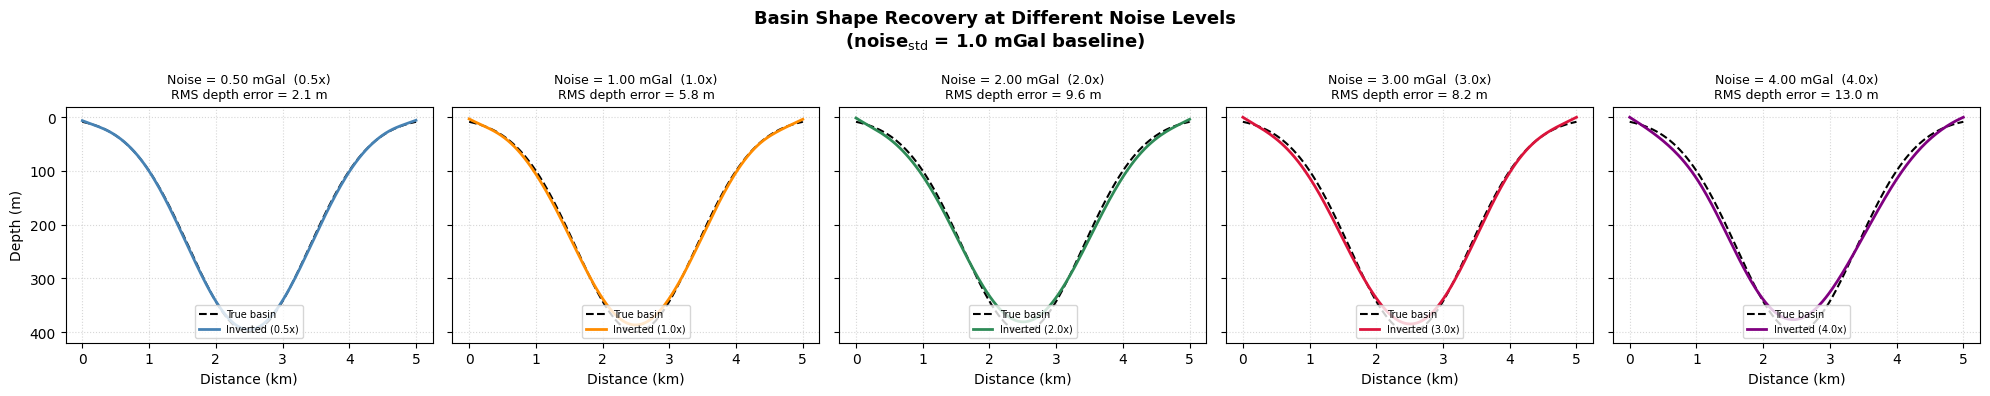

In [26]:
# ─────────────────────────────────────────────────────────────────────────
# NOISE SENSITIVITY – Figure 1: Basin shape recovery
# One subplot per noise level.
# ─────────────────────────────────────────────────────────────────────────

labels_n = [f"{m}x" for m in noise_multipliers]
colors_n = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'purple']

fig1, axes1 = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig1.suptitle(
    "Basin Shape Recovery at Different Noise Levels\n"
    r"(noise$_{\mathrm{std}}$ = 1.0 mGal baseline)",
    fontsize=13, fontweight='bold'
)

for ax, lbl, col in zip(axes1, labels_n, colors_n):
    r = noise_results[lbl]
    ax.plot(x_obs / 1000, z_true,    'k--', lw=1.5, label='True basin')
    ax.plot(x_obs / 1000, r['z_inv'], color=col, lw=2,
            label=f"Inverted ({lbl})")
    ax.invert_yaxis()
    ax.set_xlabel("Distance (km)")
    ax.set_title(
        f"Noise = {r['ns']:.2f} mGal  ({lbl})\n"
        f"RMS depth error = {r['rms_depth']:.1f} m",
        fontsize=9
    )
    ax.legend(fontsize=7, loc='lower center')
    ax.grid(True, ls=':', alpha=0.5)

axes1[0].set_ylabel("Depth (m)")
plt.tight_layout()
plt.show()


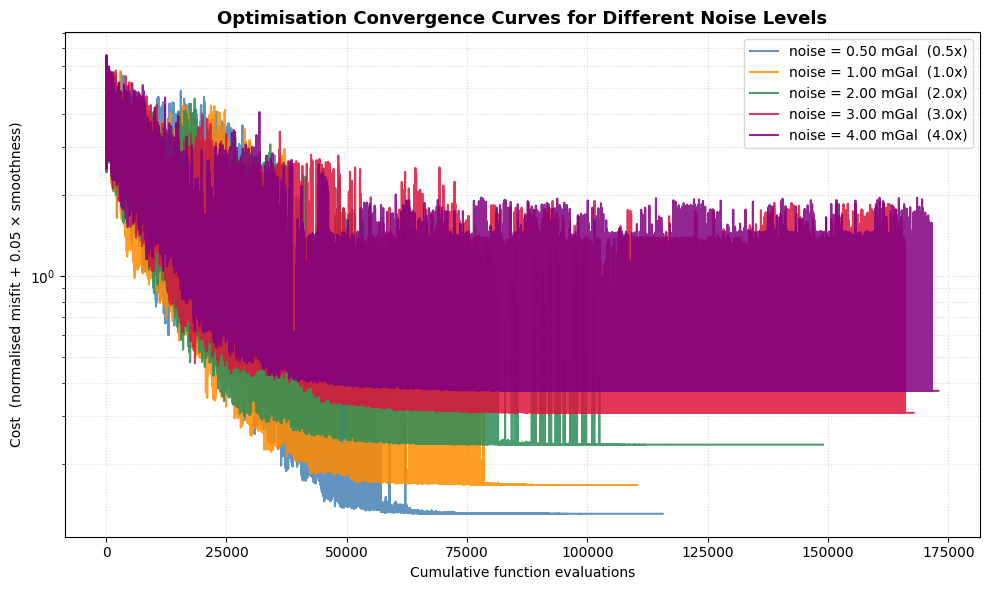

In [27]:
# ─────────────────────────────────────────────────────────────────────────
# NOISE SENSITIVITY – Figure 2: Optimisation convergence curves
# All five noise levels on one plot (log-scale y-axis).
# x-axis = cumulative function evaluations (DE + L-BFGS-B).
# ─────────────────────────────────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.set_title(
    "Optimisation Convergence Curves for Different Noise Levels",
    fontsize=13, fontweight='bold'
)

for lbl, col in zip(labels_n, colors_n):
    r   = noise_results[lbl]
    crv = r['cost_curve']
    ax2.semilogy(
        np.arange(1, len(crv) + 1), crv,
        color=col, lw=1.5, alpha=0.85,
        label=f"noise = {r['ns']:.2f} mGal  ({lbl})"
    )

ax2.set_xlabel("Cumulative function evaluations")
ax2.set_ylabel("Cost  (normalised misfit + 0.05 × smoothness)")
ax2.legend(fontsize=10)
ax2.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout()
plt.show()


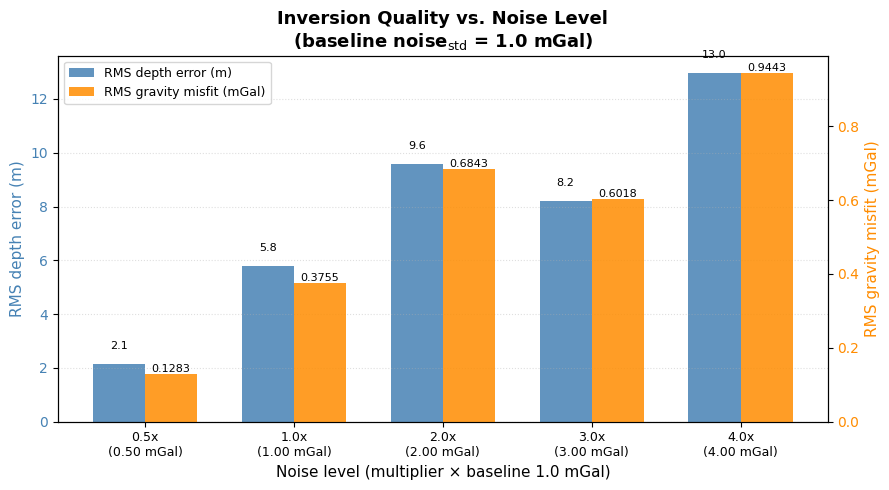


Noise Sensitivity Summary
-------------------------------------------------------
Label      Noise (mGal)   RMS Depth (m)   RMS Grav (mGal)
-------------------------------------------------------
0.5x               0.50            2.13            0.1283
1.0x               1.00            5.78            0.3755
2.0x               2.00            9.57            0.6843
3.0x               3.00            8.19            0.6018
4.0x               4.00           12.96            0.9443


In [28]:
# ─────────────────────────────────────────────────────────────────────────
# NOISE SENSITIVITY – Figure 3: Summary bar chart
# Twin-axis bar chart:
#   Left  y-axis : RMS depth error (m)
#   Right y-axis : RMS gravity misfit (mGal)
# ─────────────────────────────────────────────────────────────────────────

rms_depths = [noise_results[l]['rms_depth']   for l in labels_n]
rms_gravs  = [noise_results[l]['rms_gravity'] for l in labels_n]
x_pos      = np.arange(len(labels_n))
bw         = 0.35

fig3, ax3a = plt.subplots(figsize=(9, 5))
ax3b = ax3a.twinx()

bd = ax3a.bar(x_pos - bw / 2, rms_depths, bw,
              color='steelblue',  alpha=0.85, label='RMS depth error (m)')
bg = ax3b.bar(x_pos + bw / 2, rms_gravs,  bw,
              color='darkorange', alpha=0.85, label='RMS gravity misfit (mGal)')

# Value labels
for bar in bd:
    ax3a.text(bar.get_x() + bw / 2, bar.get_height() + 0.5,
              f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=8)
for bar in bg:
    ax3b.text(bar.get_x() + bw / 2, bar.get_height() + 0.0005,
              f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=8)

ax3a.set_xticks(x_pos)
ax3a.set_xticklabels(
    [f"{l}\n({noise_results[l]['ns']:.2f} mGal)" for l in labels_n],
    fontsize=9
)
ax3a.set_xlabel("Noise level (multiplier × baseline 1.0 mGal)", fontsize=11)
ax3a.set_ylabel("RMS depth error (m)",       color='steelblue',  fontsize=11)
ax3b.set_ylabel("RMS gravity misfit (mGal)", color='darkorange', fontsize=11)
ax3a.tick_params(axis='y', labelcolor='steelblue')
ax3b.tick_params(axis='y', labelcolor='darkorange')
ax3a.legend([bd, bg],
            ['RMS depth error (m)', 'RMS gravity misfit (mGal)'],
            loc='upper left', fontsize=9)
ax3a.set_title(
    "Inversion Quality vs. Noise Level\n"
    r"(baseline noise$_{\mathrm{std}}$ = 1.0 mGal)",
    fontsize=13, fontweight='bold'
)
ax3a.grid(True, axis='y', ls=':', alpha=0.4)
plt.tight_layout()
plt.show()

# Print summary table
print("\nNoise Sensitivity Summary")
print("-" * 55)
print(f"{'Label':<8} {'Noise (mGal)':>14} {'RMS Depth (m)':>15} {'RMS Grav (mGal)':>17}")
print("-" * 55)
for lbl in labels_n:
    r = noise_results[lbl]
    print(f"{lbl:<8} {r['ns']:>14.2f} {r['rms_depth']:>15.2f} {r['rms_gravity']:>17.4f}")


---
## Control Points Sensitivity Analysis

We test **five control-point counts** to see how parameterisation density affects inversion quality.
The five values span below, at, between, at, and above the current setting of 25:

| # | n_ctrl | Description |
|---|---|---|
| 1 | 10 | Well below 15 |
| 2 | 15 | Original baseline |
| 3 | 20 | Between 15 and 25 |
| 4 | 25 | Current best setting |
| 5 | 30 | Slightly above 25 |

For each setting the **noisy gravity** (`noise_std = 1.0 mGal`, same seed) is inverted and we record:
- **RMS depth error** (m) — basin shape accuracy
- **RMS gravity misfit** (mGal) — gravity fit quality
- **Optimisation convergence curve**

Three figures are produced:
1. Basin shape recovery (one subplot per control-point count)
2. Convergence / optimisation curves
3. Summary bar chart: quality metrics vs. control-point count

In [29]:
# ─────────────────────────────────────────────────────────────────────────
# CTRL-POINTS SENSITIVITY – Step 1:
# Factory functions that build expand_ctrl, cost, and a tracked inversion
# for an arbitrary number of control points.
# ─────────────────────────────────────────────────────────────────────────

from scipy.interpolate import interp1d
from scipy.optimize    import differential_evolution, minimize


def make_inversion_for_n_ctrl(n):
    """Return (run_fn, bounds_n) for a given number of control points n."""

    x_ctrl_n = np.linspace(x_obs.min(), x_obs.max(), n)
    bounds_n  = [(0, 500)] * n

    _hist = []

    def expand_ctrl_n(z_ctrl):
        interp = interp1d(x_ctrl_n, z_ctrl, kind='cubic', fill_value='extrapolate')
        return interp(x_obs)

    def cost_n(z_ctrl, g_obs):
        z_model = expand_ctrl_n(z_ctrl)
        xp, zp  = build_polygon(x_obs, z_model)
        g_pred  = poly_gravity(x_obs, z_obs, xp, zp, roh, t_leg, c_leg)
        misfit     = np.linalg.norm(g_pred - g_obs) / len(g_obs)
        smoothness = np.linalg.norm(np.diff(z_ctrl, n=2)) / len(z_ctrl)
        val = misfit + 0.05 * smoothness
        _hist.append(val)
        return val

    def run_fn(g_obs, seed=42):
        _hist.clear()

        res_de = differential_evolution(
            lambda z: cost_n(z, g_obs),
            bounds_n,
            strategy='best1bin', maxiter=500, popsize=20,
            mutation=(0.5, 1.0), recombination=0.9,
            tol=1e-6, seed=seed, polish=False, workers=1,
        )
        res_loc = minimize(
            lambda z: cost_n(z, g_obs),
            res_de.x, method='L-BFGS-B', bounds=bounds_n,
            options={'maxiter': 2000, 'ftol': 1e-12, 'gtol': 1e-8},
        )
        z_inv   = expand_ctrl_n(res_loc.x)
        xp, zp  = build_polygon(x_obs, z_inv)
        g_inv   = poly_gravity(x_obs, z_obs, xp, zp, roh, t_leg, c_leg)
        return z_inv, g_inv, list(_hist)

    return run_fn


In [30]:
# ─────────────────────────────────────────────────────────────────────────
# CTRL-POINTS SENSITIVITY – Step 2: run inversion for each n_ctrl.
# We use g_obs_noisy (noise_std = 1.0 mGal, same seed) throughout.
# ─────────────────────────────────────────────────────────────────────────

ctrl_counts = [10, 15, 20, 25, 30]
ctrl_results = {}

for nc in ctrl_counts:
    print(f"[n_ctrl = {nc:2d}]  running inversion …", flush=True)
    run_fn = make_inversion_for_n_ctrl(nc)
    z_inv_c, g_inv_c, cost_crv_c = run_fn(g_obs_noisy)

    rms_depth_c   = np.sqrt(np.mean((z_inv_c - z_true) ** 2))
    rms_gravity_c = np.sqrt(np.mean((g_inv_c - g_obs_clean) ** 2))

    ctrl_results[nc] = dict(
        z_inv       = z_inv_c,
        g_inv       = g_inv_c,
        cost_curve  = cost_crv_c,
        rms_depth   = rms_depth_c,
        rms_gravity = rms_gravity_c,
    )

    print(f"   → RMS depth error = {rms_depth_c:.2f} m  "
          f"| RMS gravity misfit = {rms_gravity_c:.4f} mGal")

print("\nAll control-point inversions complete.")


[n_ctrl = 10]  running inversion …
   → RMS depth error = 53.87 m  | RMS gravity misfit = 4.1192 mGal
[n_ctrl = 15]  running inversion …
   → RMS depth error = 19.65 m  | RMS gravity misfit = 1.4115 mGal
[n_ctrl = 20]  running inversion …
   → RMS depth error = 6.91 m  | RMS gravity misfit = 0.4705 mGal
[n_ctrl = 25]  running inversion …
   → RMS depth error = 3.60 m  | RMS gravity misfit = 0.2319 mGal
[n_ctrl = 30]  running inversion …
   → RMS depth error = 2.24 m  | RMS gravity misfit = 0.1470 mGal

All control-point inversions complete.


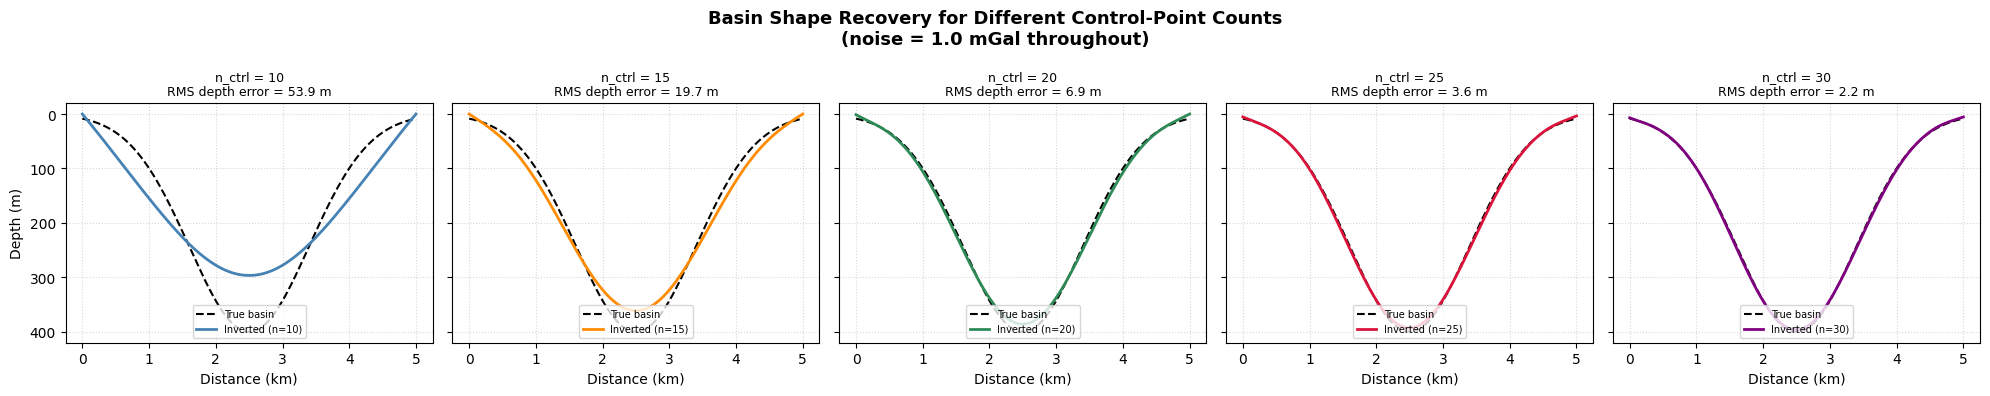

In [31]:
# ─────────────────────────────────────────────────────────────────────────
# CTRL-POINTS – Figure 1: Basin shape recovery
# ─────────────────────────────────────────────────────────────────────────

colors_c = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'purple']

fig4, axes4 = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig4.suptitle(
    "Basin Shape Recovery for Different Control-Point Counts\n"
    "(noise = 1.0 mGal throughout)",
    fontsize=13, fontweight='bold'
)

for ax, nc, col in zip(axes4, ctrl_counts, colors_c):
    r = ctrl_results[nc]
    ax.plot(x_obs / 1000, z_true,    'k--', lw=1.5, label='True basin')
    ax.plot(x_obs / 1000, r['z_inv'], color=col, lw=2,
            label=f"Inverted (n={nc})")
    ax.invert_yaxis()
    ax.set_xlabel("Distance (km)")
    ax.set_title(
        f"n_ctrl = {nc}\nRMS depth error = {r['rms_depth']:.1f} m",
        fontsize=9
    )
    ax.legend(fontsize=7, loc='lower center')
    ax.grid(True, ls=':', alpha=0.5)

axes4[0].set_ylabel("Depth (m)")
plt.tight_layout()
plt.show()


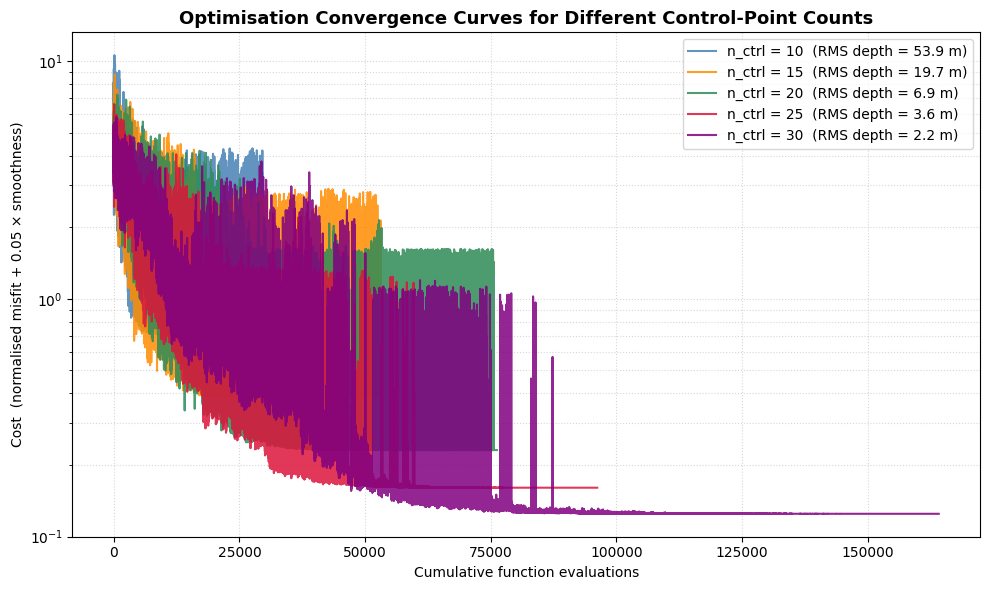

In [32]:
# ─────────────────────────────────────────────────────────────────────────
# CTRL-POINTS – Figure 2: Optimisation convergence curves
# ─────────────────────────────────────────────────────────────────────────

fig5, ax5 = plt.subplots(figsize=(10, 6))
ax5.set_title(
    "Optimisation Convergence Curves for Different Control-Point Counts",
    fontsize=13, fontweight='bold'
)

for nc, col in zip(ctrl_counts, colors_c):
    crv = ctrl_results[nc]['cost_curve']
    ax5.semilogy(
        np.arange(1, len(crv) + 1), crv,
        color=col, lw=1.5, alpha=0.85,
        label=f"n_ctrl = {nc}  (RMS depth = {ctrl_results[nc]['rms_depth']:.1f} m)"
    )

ax5.set_xlabel("Cumulative function evaluations")
ax5.set_ylabel("Cost  (normalised misfit + 0.05 × smoothness)")
ax5.legend(fontsize=10)
ax5.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout()
plt.show()


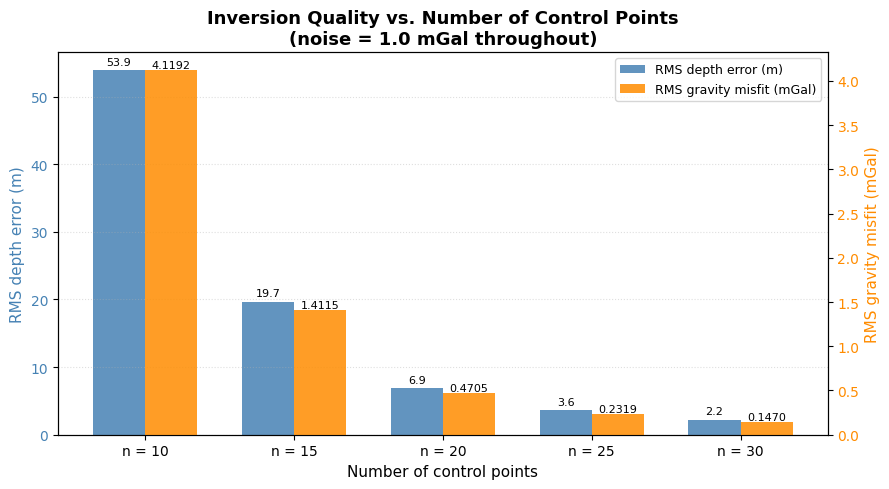


Control-Points Sensitivity Summary
----------------------------------------------------
n_ctrl       RMS Depth (m)   RMS Grav (mGal)
----------------------------------------------------
10                   53.87            4.1192
15                   19.65            1.4115
20                    6.91            0.4705
25                    3.60            0.2319
30                    2.24            0.1470


In [33]:
# ─────────────────────────────────────────────────────────────────────────
# CTRL-POINTS – Figure 3: Summary bar chart
# ─────────────────────────────────────────────────────────────────────────

rms_depths_c = [ctrl_results[nc]['rms_depth']   for nc in ctrl_counts]
rms_gravs_c  = [ctrl_results[nc]['rms_gravity'] for nc in ctrl_counts]
x_pos_c      = np.arange(len(ctrl_counts))
bw_c         = 0.35

fig6, ax6a = plt.subplots(figsize=(9, 5))
ax6b = ax6a.twinx()

bd_c = ax6a.bar(x_pos_c - bw_c / 2, rms_depths_c, bw_c,
                color='steelblue',  alpha=0.85, label='RMS depth error (m)')
bg_c = ax6b.bar(x_pos_c + bw_c / 2, rms_gravs_c,  bw_c,
                color='darkorange', alpha=0.85, label='RMS gravity misfit (mGal)')

for bar in bd_c:
    ax6a.text(bar.get_x() + bw_c / 2, bar.get_height() + 0.5,
              f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=8)
for bar in bg_c:
    ax6b.text(bar.get_x() + bw_c / 2, bar.get_height() + 0.0005,
              f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=8)

ax6a.set_xticks(x_pos_c)
ax6a.set_xticklabels(
    [f"n = {nc}" for nc in ctrl_counts], fontsize=10
)
ax6a.set_xlabel("Number of control points", fontsize=11)
ax6a.set_ylabel("RMS depth error (m)",       color='steelblue',  fontsize=11)
ax6b.set_ylabel("RMS gravity misfit (mGal)", color='darkorange', fontsize=11)
ax6a.tick_params(axis='y', labelcolor='steelblue')
ax6b.tick_params(axis='y', labelcolor='darkorange')
ax6a.legend([bd_c, bg_c],
            ['RMS depth error (m)', 'RMS gravity misfit (mGal)'],
            loc='upper right', fontsize=9)
ax6a.set_title(
    "Inversion Quality vs. Number of Control Points\n"
    "(noise = 1.0 mGal throughout)",
    fontsize=13, fontweight='bold'
)
ax6a.grid(True, axis='y', ls=':', alpha=0.4)
plt.tight_layout()
plt.show()

# Print summary table
print("\nControl-Points Sensitivity Summary")
print("-" * 52)
print(f"{'n_ctrl':<10} {'RMS Depth (m)':>15} {'RMS Grav (mGal)':>17}")
print("-" * 52)
for nc in ctrl_counts:
    r = ctrl_results[nc]
    print(f"{nc:<10} {r['rms_depth']:>15.2f} {r['rms_gravity']:>17.4f}")
